# 🔄 End-to-End ML Pipeline — Telco Customer Churn

**Objective:** Build a reusable, production-ready machine learning pipeline that predicts whether a customer will churn (cancel their subscription).

**What you'll build:**
```
Raw CSV  →  Pipeline (Preprocessing + Model)  →  GridSearchCV  →  Best Model  →  joblib export
```

**Skills covered:** `Pipeline` API · Feature preprocessing · `GridSearchCV` · Model export · Production practices

> **Dataset:** IBM Telco Customer Churn (available on Kaggle — 7,043 customers, 21 features)


## 📦 Step 1: Install & Import Libraries

In [1]:
# Colab only needs this once per session
!pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import seaborn as sns
import warnings, joblib, time, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📂 Step 2: Load Dataset


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTION A  ← uncomment this line if you have the real Kaggle CSV
# df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# OPTION B – realistic synthetic Telco dataset (7 043 rows, same columns)
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)
N = 7043

tenure        = np.random.randint(0, 72, N)
monthly_chg   = np.round(np.random.uniform(18, 118, N), 2)

# Churn probability driven by tenure + monthly charges
churn_prob = 1 / (1 + np.exp(0.05*tenure - 0.02*monthly_chg + 1.5))
churn_flag = np.random.binomial(1, churn_prob)

df = pd.DataFrame({
    'customerID'       : [f'CUST-{i:05d}' for i in range(N)],
    'gender'           : np.random.choice(['Male', 'Female'], N),
    'SeniorCitizen'    : np.random.choice([0, 1], N, p=[0.84, 0.16]),
    'Partner'          : np.random.choice(['Yes', 'No'], N),
    'Dependents'       : np.random.choice(['Yes', 'No'], N, p=[0.3, 0.7]),
    'tenure'           : tenure,
    'PhoneService'     : np.random.choice(['Yes', 'No'], N, p=[0.9, 0.1]),
    'MultipleLines'    : np.random.choice(['Yes', 'No', 'No phone service'], N),
    'InternetService'  : np.random.choice(['DSL', 'Fiber optic', 'No'], N, p=[0.34, 0.44, 0.22]),
    'OnlineSecurity'   : np.random.choice(['Yes', 'No', 'No internet service'], N),
    'OnlineBackup'     : np.random.choice(['Yes', 'No', 'No internet service'], N),
    'DeviceProtection' : np.random.choice(['Yes', 'No', 'No internet service'], N),
    'TechSupport'      : np.random.choice(['Yes', 'No', 'No internet service'], N),
    'StreamingTV'      : np.random.choice(['Yes', 'No', 'No internet service'], N),
    'StreamingMovies'  : np.random.choice(['Yes', 'No', 'No internet service'], N),
    'Contract'         : np.random.choice(['Month-to-month', 'One year', 'Two year'], N, p=[0.55, 0.24, 0.21]),
    'PaperlessBilling' : np.random.choice(['Yes', 'No'], N, p=[0.59, 0.41]),
    'PaymentMethod'    : np.random.choice(
                            ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'],
                            N, p=[0.34, 0.23, 0.22, 0.21]),
    'MonthlyCharges'   : monthly_chg,
    'TotalCharges'     : np.where(tenure == 0, ' ',
                            np.round(monthly_chg * tenure + np.random.normal(0, 50, N), 2).astype(str)),
    'Churn'            : np.where(churn_flag == 1, 'Yes', 'No'),
})

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-00000,Female,0,Yes,No,51,Yes,Yes,Fiber optic,No,...,No,No,No internet service,No internet service,Two year,Yes,Electronic check,70.02,3616.52,No
1,CUST-00001,Female,0,No,No,14,Yes,No,No,Yes,...,Yes,No internet service,No internet service,No,Two year,No,Electronic check,74.57,1020.45,No
2,CUST-00002,Female,0,Yes,No,71,Yes,No phone service,Fiber optic,Yes,...,No,No internet service,No,No internet service,Month-to-month,Yes,Electronic check,19.53,1425.12,No
3,CUST-00003,Female,0,No,No,60,Yes,No,DSL,No internet service,...,Yes,No internet service,No,No internet service,One year,Yes,Electronic check,96.06,5787.58,No
4,CUST-00004,Male,0,Yes,No,20,Yes,Yes,Fiber optic,No internet service,...,Yes,No internet service,No internet service,No,Month-to-month,Yes,Electronic check,54.16,1142.51,No


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [4]:
print("── Basic Info ──────────────────────────────────────────")
print(df.dtypes.to_string())
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts(normalize=True).mul(100).round(1).to_string()} %")

── Basic Info ──────────────────────────────────────────
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object

Missing values:
Series([], dtype: int64)

Churn distribution:
Churn
No     81.7
Yes    18.3 %


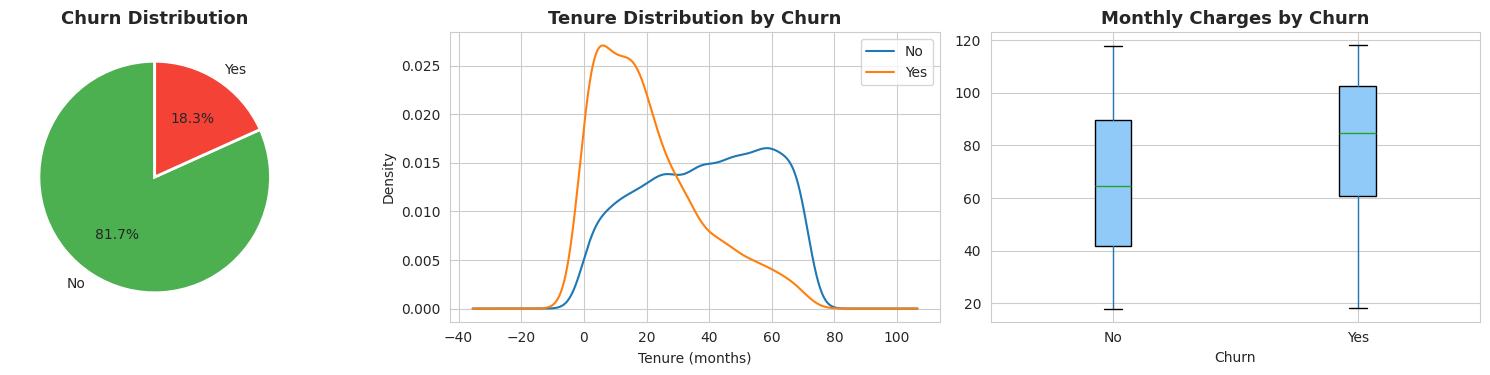

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')

# Tenure by Churn
df.groupby('Churn')['tenure'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')

# Monthly Charges by Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2],
           patch_artist=True, boxprops=dict(facecolor='#90CAF9'))
axes[2].set_title('Monthly Charges by Churn', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Churn')
plt.suptitle('')
plt.tight_layout()
plt.show()

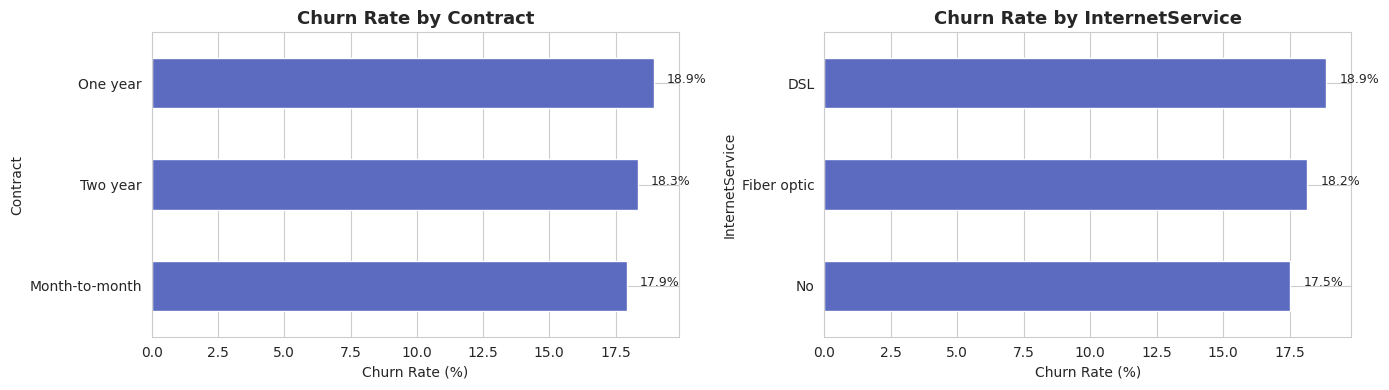

In [6]:
# Churn rate by contract type and internet service
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['Contract', 'InternetService']):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values().plot(kind='barh', ax=ax, color='#5C6BC0', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', (p.get_width() + 0.5, p.get_y() + 0.25), fontsize=9)

plt.tight_layout()
plt.show()

## 🧹 Step 4: Data Cleaning & Target Encoding

Before building the pipeline we handle the two known quirks in this dataset:
- `TotalCharges` is stored as a string and contains blank spaces for new customers (tenure = 0)
- `customerID` is a row identifier — not a feature


In [7]:
# Drop identifier column
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges: replace blanks with NaN, then cast to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Encode binary target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("✅ Cleaning done.")
print(f"TotalCharges nulls after fix: {df['TotalCharges'].isnull().sum()}")
print(f"Target classes: {df['Churn'].value_counts().to_dict()}")

✅ Cleaning done.
TotalCharges nulls after fix: 95
Target classes: {0: 5757, 1: 1286}


## ⚙️ Step 5: Define Features & Build the Pipeline

### Why use `Pipeline`?
A `Pipeline` chains preprocessing and modelling into a **single object** so:
- The same transformations run automatically on train and test data
- You can tune preprocessing AND model hyper-parameters together with `GridSearchCV`
- Saving one `.pkl` file saves the entire workflow — no missing scaler bug in production

### Architecture
```
                 ┌──────────────────────────────────────────────────────┐
  Raw DataFrame  │  ColumnTransformer                                    │
  ────────────►  │   ├─ Numeric  ─► SimpleImputer(median)  ► StandardScaler │
                 │   └─ Categoric ► SimpleImputer(most_freq) ► OneHotEncoder │
                 └──────────────┬───────────────────────────────────────┘
                                │  Transformed matrix
                                ▼
                         Classifier (LR or RF)
```


In [8]:
# ─── Feature lists ──────────────────────────────────────────────────────────
TARGET = 'Churn'
X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features    = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features  ({len(numeric_features)}): {numeric_features}")
print(f"Categorical feats ({len(categorical_features)}): {categorical_features}")

Numeric features  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical feats (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [9]:
# ─── Preprocessing sub-pipelines ────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

print("✅ Preprocessor defined.")

✅ Preprocessor defined.


In [10]:
# ─── Full pipelines (preprocessor + classifier) ─────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42)),
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42, n_jobs=-1)),
])

print("✅ LR pipeline and RF pipeline defined.")
print("\nLR pipeline steps:", [s[0] for s in lr_pipeline.steps])
print("RF pipeline steps:", [s[0] for s in rf_pipeline.steps])

✅ LR pipeline and RF pipeline defined.

LR pipeline steps: ['preprocessor', 'classifier']
RF pipeline steps: ['preprocessor', 'classifier']


## 🔀 Step 6: Train / Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]:,}  ({y_train.mean()*100:.1f}% churn)")
print(f"Test  size : {X_test.shape[0]:,}  ({y_test.mean()*100:.1f}% churn)")

Train size : 5,634  (18.3% churn)
Test  size : 1,409  (18.2% churn)


## 🔎 Step 7: Hyperparameter Tuning with GridSearchCV

`GridSearchCV` tries **every combination** of the hyper-parameter grid and selects the best one using **5-fold stratified cross-validation** on the training set.

> ⏳ Grid search takes a couple of minutes on Colab — keep `n_jobs=-1` to use all CPU cores.


In [12]:
# ─── Logistic Regression grid ───────────────────────────────────────────────
lr_param_grid = {
    'classifier__C'       : [0.01, 0.1, 1, 10],        # inverse regularisation strength
    'classifier__solver'  : ['lbfgs', 'liblinear'],
    'classifier__penalty' : ['l2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("🔎 Running GridSearchCV for Logistic Regression ...")
t0 = time.time()

lr_gs = GridSearchCV(
    estimator  = lr_pipeline,
    param_grid = lr_param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
)
lr_gs.fit(X_train, y_train)

print(f"\n✅ LR Grid search done in {time.time()-t0:.1f}s")
print(f"   Best params : {lr_gs.best_params_}")
print(f"   Best CV AUC : {lr_gs.best_score_:.4f}")

🔎 Running GridSearchCV for Logistic Regression ...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ LR Grid search done in 7.6s
   Best params : {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
   Best CV AUC : 0.7794


In [13]:
# ─── Random Forest grid ─────────────────────────────────────────────────────
rf_param_grid = {
    'classifier__n_estimators' : [100, 200],
    'classifier__max_depth'    : [5, 10, None],
    'classifier__min_samples_split' : [2, 5],
}

print("🔎 Running GridSearchCV for Random Forest ...")
t0 = time.time()

rf_gs = GridSearchCV(
    estimator  = rf_pipeline,
    param_grid = rf_param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
)
rf_gs.fit(X_train, y_train)

print(f"\n✅ RF Grid search done in {time.time()-t0:.1f}s")
print(f"   Best params : {rf_gs.best_params_}")
print(f"   Best CV AUC : {rf_gs.best_score_:.4f}")

🔎 Running GridSearchCV for Random Forest ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ RF Grid search done in 59.3s
   Best params : {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
   Best CV AUC : 0.7660


## 📊 Step 8: Evaluate on the Test Set

In [14]:
def evaluate_model(gs_object, X_test, y_test, name):
    """Print metrics + return predictions for plotting."""
    y_pred  = gs_object.predict(X_test)
    y_proba = gs_object.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['No Churn','Churn'])}")
    return y_pred, y_proba

lr_pred, lr_proba = evaluate_model(lr_gs, X_test, y_test, "Logistic Regression")
rf_pred, rf_proba = evaluate_model(rf_gs, X_test, y_test, "Random Forest")


  Logistic Regression
  Accuracy : 82.61%
  ROC-AUC  : 0.7839

              precision    recall  f1-score   support

    No Churn       0.83      0.98      0.90      1152
       Churn       0.62      0.12      0.20       257

    accuracy                           0.83      1409
   macro avg       0.73      0.55      0.55      1409
weighted avg       0.79      0.83      0.77      1409


  Random Forest
  Accuracy : 81.76%
  ROC-AUC  : 0.7720

              precision    recall  f1-score   support

    No Churn       0.82      1.00      0.90      1152
       Churn       0.00      0.00      0.00       257

    accuracy                           0.82      1409
   macro avg       0.41      0.50      0.45      1409
weighted avg       0.67      0.82      0.74      1409



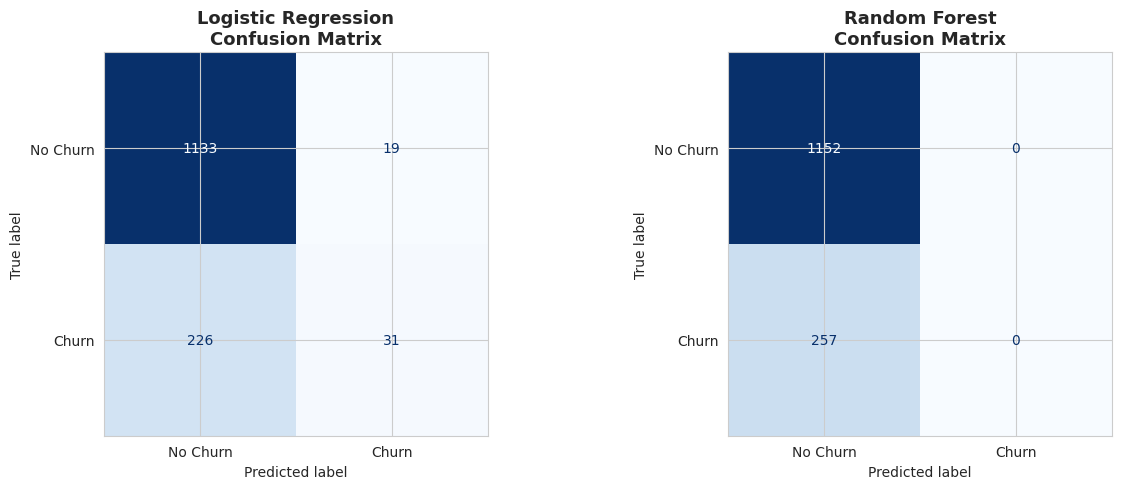

In [15]:
# ─── Confusion Matrices ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, title in zip(axes,
                            [lr_pred, rf_pred],
                            ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

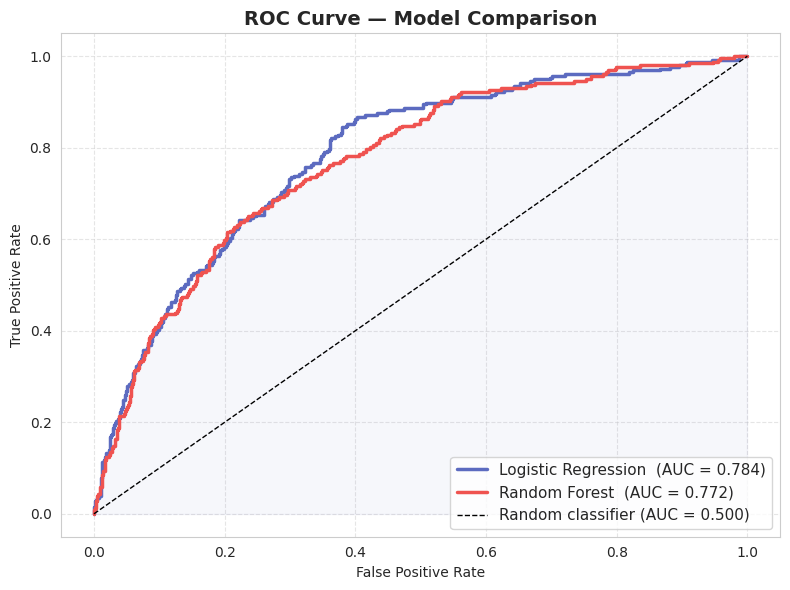

In [16]:
# ─── ROC Curve Comparison ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for proba, label, color in [
        (lr_proba, 'Logistic Regression', '#5C6BC0'),
        (rf_proba, 'Random Forest',       '#EF5350')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{label}  (AUC = {auc:.3f})', linewidth=2.5, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.05, color='#5C6BC0')
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 🌲 Step 9: Feature Importance (Random Forest)

Because `RandomForest` is wrapped inside a `Pipeline`, we need to unpack the preprocessor's feature names before plotting.


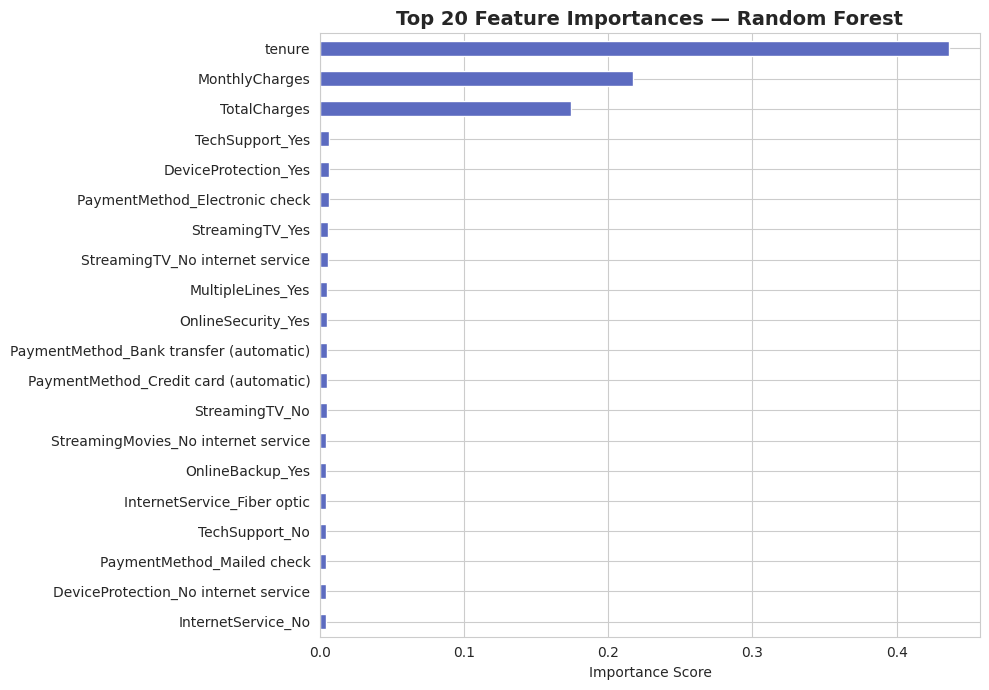

In [17]:
# Extract fitted preprocessor from the best RF pipeline
best_rf_pipeline = rf_gs.best_estimator_
fitted_preprocessor = best_rf_pipeline.named_steps['preprocessor']
rf_clf              = best_rf_pipeline.named_steps['classifier']

# Get feature names after OHE
num_names = numeric_features
cat_names = list(
    fitted_preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_features)
)
all_feature_names = num_names + cat_names

# Build importance series
importances = pd.Series(rf_clf.feature_importances_, index=all_feature_names)
top20 = importances.nlargest(20).sort_values()

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color='#5C6BC0', edgecolor='white')
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 💾 Step 10: Export the Pipeline with `joblib`

We save the **complete pipeline** — preprocessing + trained model — as a single `.pkl` file.
Loading it later gives you a ready-to-use predictor with zero extra work.


In [18]:
# Choose the best model (higher AUC wins)
lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

best_model  = lr_gs.best_estimator_ if lr_auc >= rf_auc else rf_gs.best_estimator_
best_name   = "Logistic Regression" if lr_auc >= rf_auc else "Random Forest"
best_auc    = max(lr_auc, rf_auc)

print(f"🏆 Best model: {best_name}  (Test AUC = {best_auc:.4f})")

MODEL_PATH = "telco_churn_pipeline.pkl"
joblib.dump(best_model, MODEL_PATH)
print(f"\n✅ Pipeline saved → '{MODEL_PATH}'  ({os.path.getsize(MODEL_PATH)/1024:.1f} KB)")

🏆 Best model: Logistic Regression  (Test AUC = 0.7839)

✅ Pipeline saved → 'telco_churn_pipeline.pkl'  (8.4 KB)


In [19]:
# ─── Reload & verify ─────────────────────────────────────────────────────────
loaded_pipeline = joblib.load(MODEL_PATH)

sample = X_test.iloc[:5]
preds  = loaded_pipeline.predict(sample)
probas = loaded_pipeline.predict_proba(sample)[:, 1]

results = sample[['tenure', 'MonthlyCharges', 'Contract']].copy()
results['Predicted_Churn'] = ['Yes' if p == 1 else 'No' for p in preds]
results['Churn_Probability'] = probas.round(3)

print("🔍 Sample predictions from reloaded pipeline:\n")
print(results.to_string())

🔍 Sample predictions from reloaded pipeline:

      tenure  MonthlyCharges        Contract Predicted_Churn  Churn_Probability
6078      13          116.19  Month-to-month             Yes              0.538
6395      13           28.05        One year              No              0.161
1290      61           43.36        Two year              No              0.048
5412      54           63.00        One year              No              0.074
1186      33           64.90  Month-to-month              No              0.141


## 📋 Step 11: Model Summary Dashboard

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for name, gs, proba, pred in [
        ('Logistic Regression', lr_gs, lr_proba, lr_pred),
        ('Random Forest',       rf_gs, rf_proba, rf_pred)]:
    rows.append({
        'Model'      : name,
        'Best Params': str(gs.best_params_),
        'CV AUC'     : round(gs.best_score_, 4),
        'Test AUC'   : round(roc_auc_score(y_test, proba), 4),
        'Accuracy'   : round(accuracy_score(y_test, pred)*100, 2),
        'Precision'  : round(precision_score(y_test, pred)*100, 2),
        'Recall'     : round(recall_score(y_test, pred)*100, 2),
        'F1-Score'   : round(f1_score(y_test, pred)*100, 2),
    })

summary = pd.DataFrame(rows).set_index('Model')
print("\n📊 Model Comparison Summary")
print(summary.T.to_string())


📊 Model Comparison Summary
Model                                                                        Logistic Regression                                                                                      Random Forest
Best Params  {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}  {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
CV AUC                                                                                    0.7794                                                                                              0.766
Test AUC                                                                                  0.7839                                                                                              0.772
Accuracy                                                                                   82.61                                                                                            

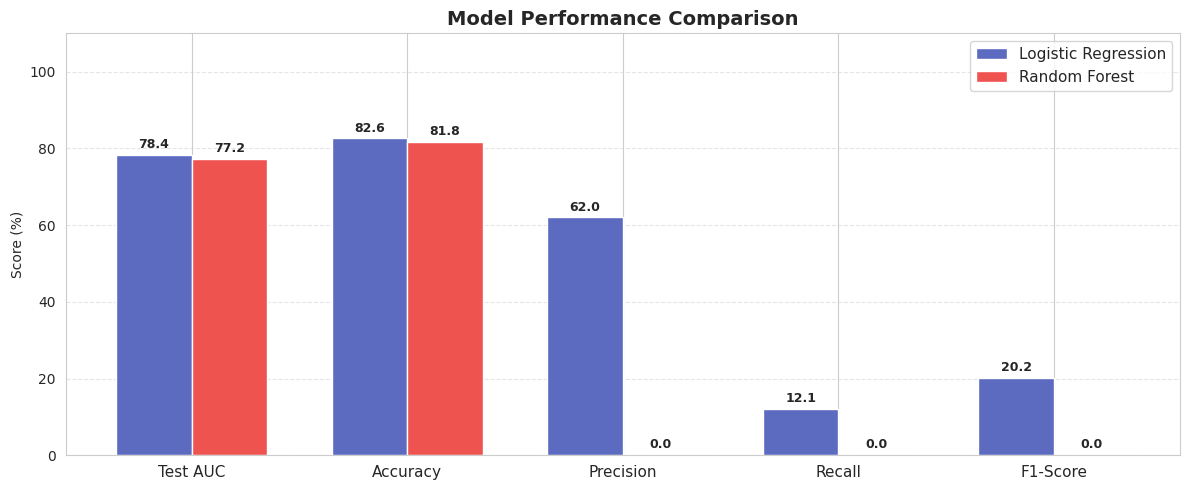

In [21]:
# ─── Visual summary bar chart ────────────────────────────────────────────────
metrics   = ['Test AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [summary.loc['Logistic Regression', m] for m in metrics]
rf_scores = [summary.loc['Random Forest',       m] for m in metrics]

# Normalise AUC to 0-100 for consistent y-axis
lr_scores[0] *= 100
rf_scores[0] *= 100

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#5C6BC0', edgecolor='white')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest',       color='#EF5350', edgecolor='white')

ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()